# Sinusoid Laplace — 5-Seed Evaluation

Same variants as `sinusoidal_laplace.ipynb` but run over 5 random seeds. Checkpoints and figures use the `sinusoid_laplace_5seed` prefix to avoid any overlap with the single-seed outputs.

In [1]:
from pathlib import Path
import sys, os, time, copy
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from laplace import Laplace
from scipy.stats import norm as _norm

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "shared").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from shared import (checkpoint_exists, load_checkpoint, save_checkpoint,
                    seed_everything, regression_metrics, load_sinusoid)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

SEEDS = [711, 42, 123, 456, 789]
sigma_noise = 0.3
TRAIN_LO, TRAIN_HI = 0.0, 8.0

FIGURES_DIR = os.path.join("..", "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

CHECKPOINT_BASE = str(ROOT / "results" / "checkpoints" / "sinusoid_laplace_5seed")
os.makedirs(CHECKPOINT_BASE, exist_ok=True)

plt.rcParams.update({"font.family": "serif", "font.size": 12,
                     "savefig.dpi": 150, "savefig.bbox": "tight"})
print(f"5-seed Laplace regression | {len(SEEDS)} seeds | checkpoints -> {CHECKPOINT_BASE}")

Device: cuda
5-seed Laplace regression | 5 seeds | checkpoints -> /u/halle/carg/home_at/Documents/BNNs/results/checkpoints/sinusoid_laplace_5seed


In [2]:
# Deterministic evaluation grid (torch.linspace — independent of seed)
x_grid = torch.linspace(-5, 13, 500).numpy()

def get_model(seed):
    seed_everything(seed)
    return torch.nn.Sequential(
        torch.nn.Linear(1, 50), torch.nn.Tanh(), torch.nn.Linear(50, 1))

def la_predict(la_model, X):
    f_mu, f_var = la_model(X)
    return f_mu.squeeze().detach().cpu().numpy(), f_var.squeeze().sqrt().detach().cpu().numpy()

# Variant specs — identical to single-seed notebook
variant_specs = []
for subset, hessians in [("all", ["diag", "kron", "full"]), ("last_layer", ["full", "kron"])]:
    scope = "all" if subset == "all" else "last layer"
    for hessian in hessians:
        for tune in ["marglik", "gridsearch"]:
            variant_specs.append({
                "variant_name": f"{hessian}_{subset}_{tune}",
                "hessian": hessian, "subset": subset, "tune": tune,
                "plot_title": f"{hessian.capitalize()} / {scope} / {tune}",
            })
for subset in ["all", "last_layer"]:
    scope = "all" if subset == "all" else "last layer"
    variant_specs.append({
        "variant_name": f"kron_{subset}_adam_loop",
        "hessian": "kron", "subset": subset, "tune": "adam_loop",
        "plot_title": f"Kron / {scope} / adam loop",
    })
print(f"Configured {len(variant_specs)} variants x {len(SEEDS)} seeds = "
      f"{len(variant_specs)*len(SEEDS)} total fits")


Configured 12 variants x 5 seeds = 60 total fits


In [3]:
all_seed_metrics = {}   # {seed: {vname: metrics_dict}}
all_seed_preds   = {}   # {seed: {vname: (f_mu_grid, epi_grid, sigma)}}
all_seed_la      = {}   # {seed: {vname: fitted Laplace object}}

for seed in SEEDS:
    print(f"\n{'='*55}\nSEED {seed}  ({SEEDS.index(seed)+1}/{len(SEEDS)})\n{'='*55}")

    # ----- data -----
    d = load_sinusoid(n_data=150, sigma_noise=sigma_noise, batch_size=150, seed=seed,
                      device=torch.device("cpu"))
    X_train, y_train = d["X_train"], d["y_train"]
    train_loader     = d["train_loader"]
    X_val, y_val     = d["X_val"], d["y_val"]
    val_loader       = d["val_loader"]
    X_test_id, y_test_id = d["X_test_id"], d["y_test_id"]
    y_test_id_np = y_test_id.flatten().numpy()

    # ----- MAP -----
    criterion = torch.nn.MSELoss()
    X_test_grid = torch.linspace(-5, 13, 500).unsqueeze(-1)
    map_ckpt = os.path.join(CHECKPOINT_BASE, f"sinusoid_map_seed{seed}.pt")
    map_model = get_model(seed)
    if checkpoint_exists(map_ckpt):
        map_model.load_state_dict(
            load_checkpoint(map_ckpt, map_location="cpu")["model_state_dict"])
        print("  MAP: loaded checkpoint")
    else:
        opt = torch.optim.Adam(map_model.parameters(), lr=1e-2)
        t0 = time.time()
        for _ in range(1000):
            for xb, yb in train_loader:
                opt.zero_grad(); loss = criterion(map_model(xb), yb); loss.backward(); opt.step()
        save_checkpoint({"model_state_dict": map_model.state_dict(),
                         "fit_time": time.time()-t0}, map_ckpt)
        print(f"  MAP: trained ({time.time()-t0:.1f}s)")
    map_model.eval()
    with torch.no_grad():
        map_resid_std = float((y_train - map_model(X_train)).std().item())

    seed_metrics, seed_preds = {}, {}
    for spec in variant_specs:
        vname = spec["variant_name"]
        la_ckpt = os.path.join(CHECKPOINT_BASE, f"sinusoid_laplace_{vname}_seed{seed}.pt")

        # Build Laplace from a fresh copy of the MAP weights
        base = get_model(seed)
        base.load_state_dict(map_model.state_dict())
        la = Laplace(base, "regression",
                     subset_of_weights=spec["subset"],
                     hessian_structure=spec["hessian"])

        loaded = False
        if checkpoint_exists(la_ckpt):
            payload = load_checkpoint(la_ckpt)
            if isinstance(payload, dict) and payload.get("la") is not None:
                la = payload["la"]; metrics = payload.get("metrics", {}); loaded = True
            elif isinstance(payload, dict) and payload.get("la_state_dict") is not None:
                la.fit(train_loader); la.load_state_dict(payload["la_state_dict"])
                metrics = payload.get("metrics", {})
                save_checkpoint({"la": la, "la_state_dict": la.state_dict(),
                                 "metrics": metrics}, la_ckpt)
                loaded = True

        if not loaded:
            t0 = time.time(); la.fit(train_loader)
            metrics = {
                "Hessian_Structure": spec["hessian"],
                "Subset_Of_Weights": spec["subset"],
                "Tune_Method": spec["tune"],
                "Fit_Time (s)": time.time()-t0,
            }
            t1 = time.time()
            if spec["tune"] == "adam_loop":
                log_prior = torch.ones(1, requires_grad=True)
                log_sigma = torch.ones(1, requires_grad=True)
                hyp_opt = torch.optim.Adam([log_prior, log_sigma], lr=1e-1)
                for _ in range(1000):
                    hyp_opt.zero_grad()
                    (-la.log_marginal_likelihood(log_prior.exp(), log_sigma.exp())).backward()
                    hyp_opt.step()
                la.prior_precision = log_prior.exp().detach()
                la.sigma_noise = log_sigma.exp().detach()
            else:
                la.sigma_noise = torch.tensor(map_resid_std)
                if spec["tune"] == "marglik":
                    la.optimize_prior_precision(method="marglik")
                else:
                    la.optimize_prior_precision(method="gridsearch", val_loader=val_loader)
            metrics["Tune_Time (s)"] = time.time()-t1
            metrics["Prior_Precision"] = float(
                np.atleast_1d(la.prior_precision.detach().cpu().numpy())[0])
            metrics["Sigma_Noise"] = float(la.sigma_noise.item())
            save_checkpoint({"la": la, "la_state_dict": la.state_dict(),
                             "metrics": metrics}, la_ckpt)

        sigma = float(la.sigma_noise.item())
        metrics["Sigma_Noise"] = sigma
        metrics["Prior_Precision"] = float(
            np.atleast_1d(la.prior_precision.detach().cpu().numpy())[0])

        f_mu_grid, epi_grid = la_predict(la, X_test_grid)
        t_inf = time.time()
        mu_id, epi_id = la_predict(la, X_test_id)
        metrics["Inf_Time (s)"] = time.time() - t_inf
        total_id = np.sqrt(epi_id**2 + sigma**2)
        metrics.update(regression_metrics(y_test_id_np, mu_id, total_id))

        seed_metrics[vname] = metrics
        seed_preds[vname] = (f_mu_grid, epi_grid, sigma)
        all_seed_la.setdefault(seed, {})[vname] = la
        print(f"  {vname}: RMSE={metrics.get('RMSE',float('nan')):.4f}  "
              f"NLL={metrics.get('NLL',float('nan')):.4f}  "
              f"Cal={metrics.get('Calibration_MAE',float('nan')):.4f}")

    all_seed_metrics[seed] = seed_metrics
    all_seed_preds[seed] = seed_preds

print(f"\nCompleted {len(SEEDS)} seeds x {len(variant_specs)} variants.")


SEED 711  (1/5)
  MAP: trained (43.2s)
  diag_all_marglik: RMSE=0.3006  NLL=0.3159  Cal=0.1174
  diag_all_gridsearch: RMSE=0.3006  NLL=0.2872  Cal=0.1008
  kron_all_marglik: RMSE=0.3006  NLL=0.2341  Cal=0.0568
  kron_all_gridsearch: RMSE=0.3006  NLL=0.2279  Cal=0.0442
  full_all_marglik: RMSE=0.3006  NLL=0.2285  Cal=0.0454
  full_all_gridsearch: RMSE=0.3006  NLL=0.2236  Cal=0.0354
  full_last_layer_marglik: RMSE=0.3006  NLL=0.2251  Cal=0.0408
  full_last_layer_gridsearch: RMSE=0.3006  NLL=0.2232  Cal=0.0348
  kron_last_layer_marglik: RMSE=0.3006  NLL=0.2256  Cal=0.0410
  kron_last_layer_gridsearch: RMSE=0.3006  NLL=0.2242  Cal=0.0390


/u/halle/carg/home_at/anaconda3/envs/bnn/lib/python3.12/site-packages/laplace/utils/matrix.py:373: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:838.)
  [pow(scalar, 1 / len(ls)) * eigval for eigval in ls]


  kron_all_adam_loop: RMSE=0.3006  NLL=0.2332  Cal=0.0554
  kron_last_layer_adam_loop: RMSE=0.3006  NLL=0.2250  Cal=0.0408

SEED 42  (2/5)
  MAP: trained (72.2s)
  diag_all_marglik: RMSE=0.3254  NLL=0.3214  Cal=0.0484
  diag_all_gridsearch: RMSE=0.3254  NLL=0.3277  Cal=0.0568
  kron_all_marglik: RMSE=0.3254  NLL=0.3031  Cal=0.0266
  kron_all_gridsearch: RMSE=0.3254  NLL=0.3031  Cal=0.0260
  full_all_marglik: RMSE=0.3254  NLL=0.3048  Cal=0.0392
  full_all_gridsearch: RMSE=0.3254  NLL=0.3089  Cal=0.0448
  full_last_layer_marglik: RMSE=0.3254  NLL=0.3084  Cal=0.0442
  full_last_layer_gridsearch: RMSE=0.3254  NLL=0.3092  Cal=0.0460
  kron_last_layer_marglik: RMSE=0.3254  NLL=0.3077  Cal=0.0432
  kron_last_layer_gridsearch: RMSE=0.3254  NLL=0.3070  Cal=0.0426
  kron_all_adam_loop: RMSE=0.3254  NLL=0.3035  Cal=0.0270
  kron_last_layer_adam_loop: RMSE=0.3254  NLL=0.3085  Cal=0.0448

SEED 123  (3/5)
  MAP: trained (66.0s)
  diag_all_marglik: RMSE=0.3238  NLL=0.3083  Cal=0.0384
  diag_all_grids

In [4]:
# Aggregate metrics across seeds (mean ± std per variant)
metric_keys = [
    "RMSE", "MAE", "NLL",
    "Calibration_MAE", "Calibration_MSE", "Calibration_Corr", "Max_Calibration_Gap",
    "Coverage_68", "Coverage_95",
    "Fit_Time (s)", "Tune_Time (s)", "Inf_Time (s)",
]

agg = {}
for spec in variant_specs:
    vname = spec["variant_name"]
    agg[vname] = {}
    for mk in metric_keys:
        vals = [all_seed_metrics[s][vname].get(mk, float("nan")) for s in SEEDS]
        vals = [v for v in vals if not np.isnan(v)]
        agg[vname][f"{mk}_mean"] = float(np.mean(vals)) if vals else float("nan")
        agg[vname][f"{mk}_std"]  = float(np.std(vals))  if len(vals)>1 else 0.0

# Display as mean ± std table
rows = []
for spec in variant_specs:
    vname = spec["variant_name"]
    row = {mk: f"{agg[vname][f'{mk}_mean']:.4f} ± {agg[vname][f'{mk}_std']:.4f}"
           for mk in metric_keys}
    rows.append(row)
summary_df = pd.DataFrame(rows, index=[s["plot_title"] for s in variant_specs])
summary_df.index.name = "Variant"
print(f"Sinusoid Laplace — {len(SEEDS)}-seed metrics (mean ± std)")
display(summary_df)

# Save raw means/stds for downstream use
agg_flat = []
for spec in variant_specs:
    vname = spec["variant_name"]
    row = {"Variant": spec["plot_title"]}
    row.update(agg[vname])
    agg_flat.append(row)
agg_df = pd.DataFrame(agg_flat).set_index("Variant")
os.makedirs("results/metrics", exist_ok=True)
agg_df.to_csv("results/metrics/sinusoid_laplace_5seed_metrics.csv")
print("\nSaved to results/metrics/sinusoid_laplace_5seed_metrics.csv")


Sinusoid Laplace — 5-seed metrics (mean ± std)


,RMSE,MAE,NLL,Calibration_MAE,Calibration_MSE,Calibration_Corr,Max_Calibration_Gap,Coverage_68,Coverage_95,Fit_Time (s),Tune_Time (s),Inf_Time (s)
Variant,,,,,,,,,,,,
Diag / all / marglik,0.3173 ± 0.0089,0.2539 ± 0.0086,0.3235 ± 0.0110,0.0760 ± 0.0289,0.0080 ± 0.0052,0.9936 ± 0.0042,0.1261 ± 0.0439,0.7936 ± 0.0468,0.9832 ± 0.0082,0.1734 ± 0.0469,0.0576 ± 0.0157,0.2980 ± 0.0244
Diag / all / gridsearch,0.3173 ± 0.0089,0.2539 ± 0.0086,0.3116 ± 0.0260,0.0636 ± 0.0345,0.0063 ± 0.0051,0.9948 ± 0.0047,0.1066 ± 0.0553,0.7720 ± 0.0513,0.9816 ± 0.0135,0.1766 ± 0.0093,10.8830 ± 1.3645,0.2721 ± 0.0287
Kron / all / marglik,0.3173 ± 0.0089,0.2539 ± 0.0086,0.2763 ± 0.0244,0.0323 ± 0.0143,0.0015 ± 0.0012,0.9986 ± 0.0007,0.0626 ± 0.0192,0.7000 ± 0.0509,0.9528 ± 0.0163,0.5081 ± 0.0652,0.0764 ± 0.0287,0.4276 ± 0.0205
Kron / all / gridsearch,0.3173 ± 0.0089,0.2539 ± 0.0086,0.2738 ± 0.0252,0.0284 ± 0.0120,0.0012 ± 0.0008,0.9986 ± 0.0009,0.0549 ± 0.0183,0.7000 ± 0.0526,0.9520 ± 0.0126,0.5084 ± 0.0586,14.5525 ± 2.2504,0.4012 ± 0.0466
Full / all / marglik,0.3173 ± 0.0089,0.2539 ± 0.0086,0.2763 ± 0.0288,0.0327 ± 0.0160,0.0015 ± 0.0011,0.9987 ± 0.0004,0.0583 ± 0.0240,0.6880 ± 0.0493,0.9440 ± 0.0198,5.3987 ± 2.4105,12.8536 ± 2.4717,0.2735 ± 0.0356
Full / all / gridsearch,0.3173 ± 0.0089,0.2539 ± 0.0086,0.2758 ± 0.0314,0.0324 ± 0.0150,0.0015 ± 0.0011,0.9987 ± 0.0005,0.0601 ± 0.0216,0.6768 ± 0.0449,0.9432 ± 0.0203,5.5491 ± 2.3150,19.4416 ± 2.6854,0.2861 ± 0.0553
Full / last layer / marglik,0.3173 ± 0.0089,0.2539 ± 0.0086,0.2782 ± 0.0319,0.0327 ± 0.0179,0.0016 ± 0.0012,0.9986 ± 0.0004,0.0605 ± 0.0235,0.6744 ± 0.0449,0.9424 ± 0.0199,0.1260 ± 0.0457,4.2892 ± 0.8991,0.0968 ± 0.0148
Full / last layer / gridsearch,0.3173 ± 0.0089,0.2539 ± 0.0086,0.2762 ± 0.0316,0.0323 ± 0.0162,0.0015 ± 0.0012,0.9986 ± 0.0005,0.0608 ± 0.0210,0.6704 ± 0.0446,0.9424 ± 0.0199,0.1186 ± 0.0320,9.0984 ± 1.8993,0.1081 ± 0.0154
Kron / last layer / marglik,0.3173 ± 0.0089,0.2539 ± 0.0086,0.2780 ± 0.0314,0.0325 ± 0.0174,0.0016 ± 0.0012,0.9986 ± 0.0004,0.0598 ± 0.0228,0.6752 ± 0.0452,0.9424 ± 0.0199,0.2322 ± 0.0385,0.0685 ± 0.0281,0.0954 ± 0.0204



Saved to results/metrics/sinusoid_laplace_5seed_metrics.csv


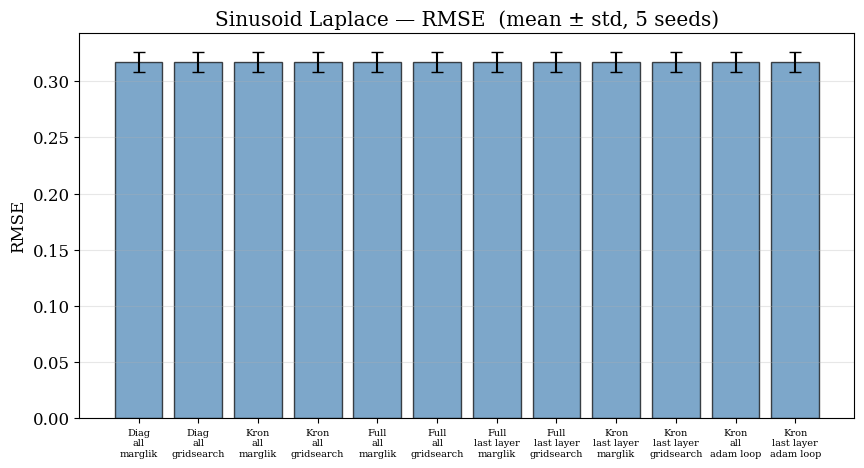

Saved: 5seed_sinusoid_laplace_rmse_bar.png


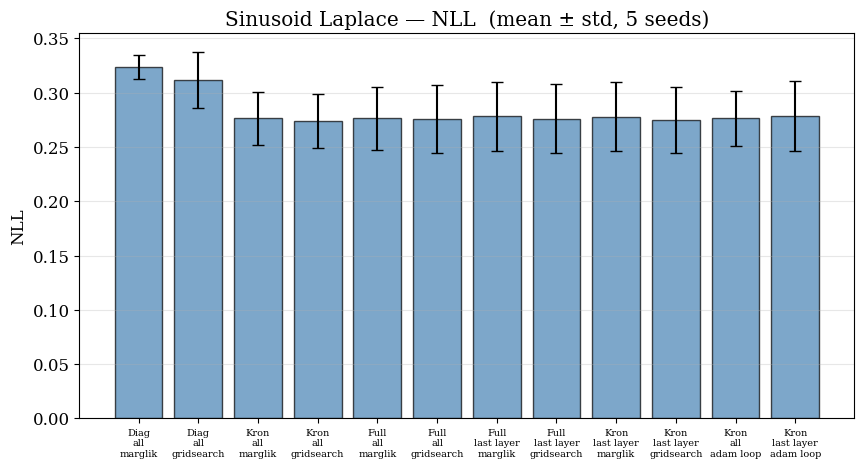

Saved: 5seed_sinusoid_laplace_nll_bar.png


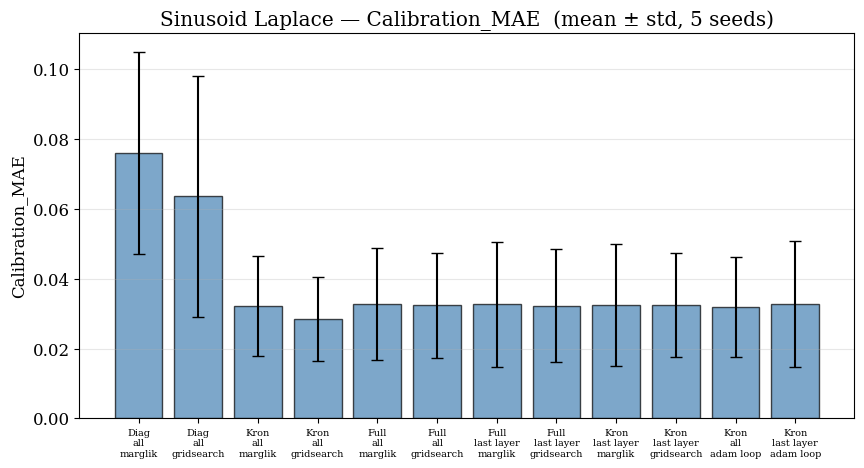

Saved: 5seed_sinusoid_laplace_calibration_mae_bar.png


In [5]:
plot_metrics = ["RMSE", "NLL", "Calibration_MAE"]
titles = [s["plot_title"] for s in variant_specs]
n = len(titles)
x = np.arange(n)

for mk in plot_metrics:
    means = [agg[s["variant_name"]][f"{mk}_mean"] for s in variant_specs]
    stds  = [agg[s["variant_name"]][f"{mk}_std"]  for s in variant_specs]
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x, means, yerr=stds, capsize=4, color="steelblue", alpha=0.7, edgecolor="k")
    ax.set_xticks(x)
    ax.set_xticklabels([t.replace(" / ", "\n") for t in titles], fontsize=7)
    ax.set_ylabel(mk)
    ax.set_title(f"Sinusoid Laplace — {mk}  (mean ± std, {len(SEEDS)} seeds)")
    ax.grid(True, alpha=0.3, axis="y")
    fname = f"5seed_sinusoid_laplace_{mk.lower()}_bar.png"
    fig.savefig(os.path.join(FIGURES_DIR, fname), dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")


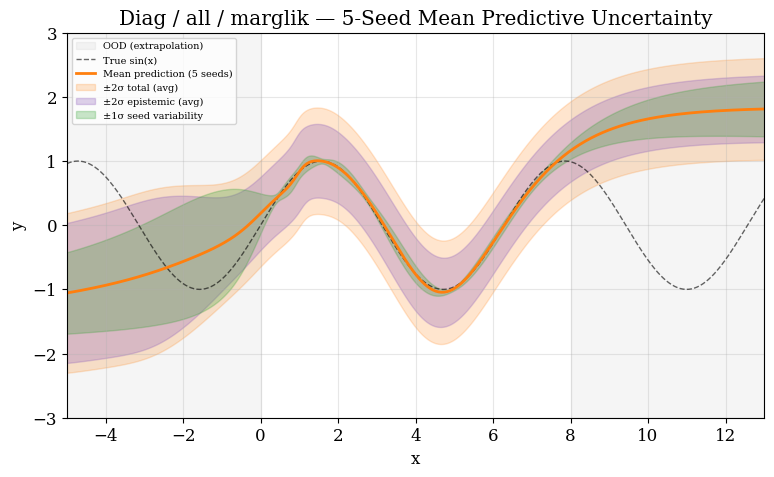

  Saved: 5seed_sinusoid_diag_all_marglik_prediction.png


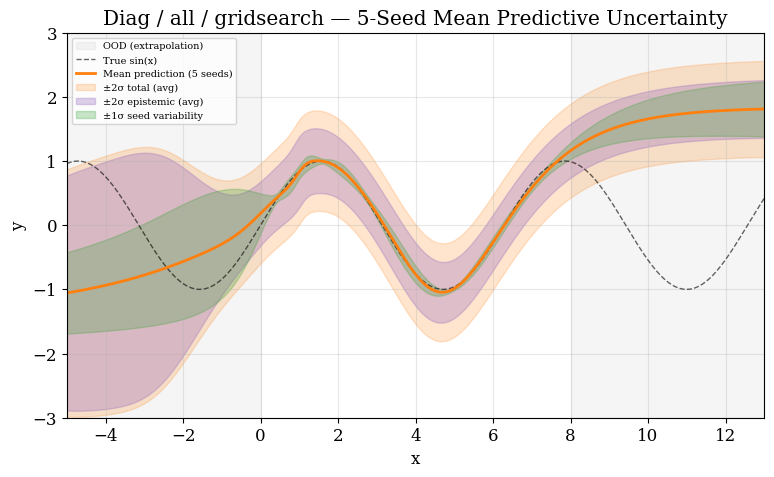

  Saved: 5seed_sinusoid_diag_all_gridsearch_prediction.png


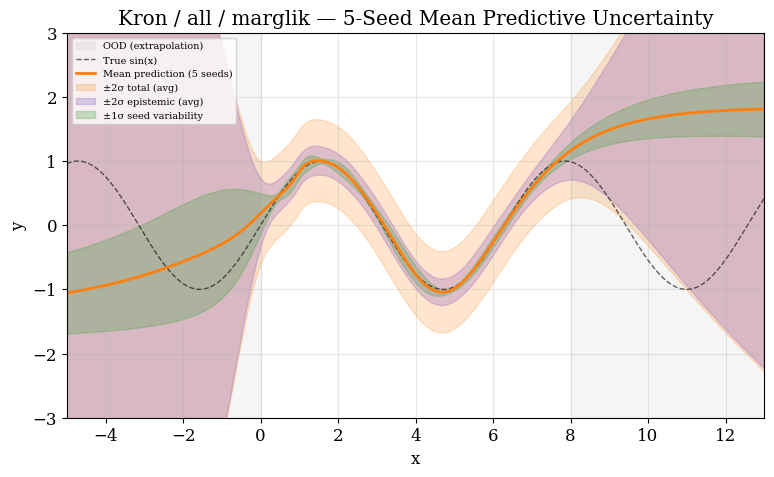

  Saved: 5seed_sinusoid_kron_all_marglik_prediction.png


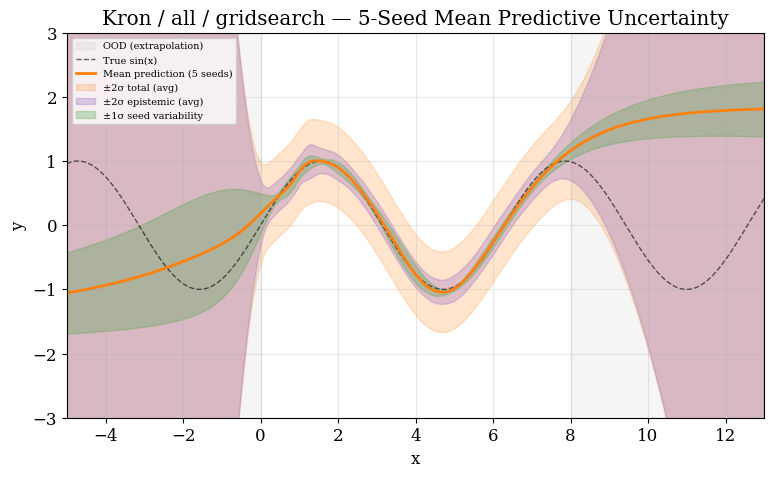

  Saved: 5seed_sinusoid_kron_all_gridsearch_prediction.png


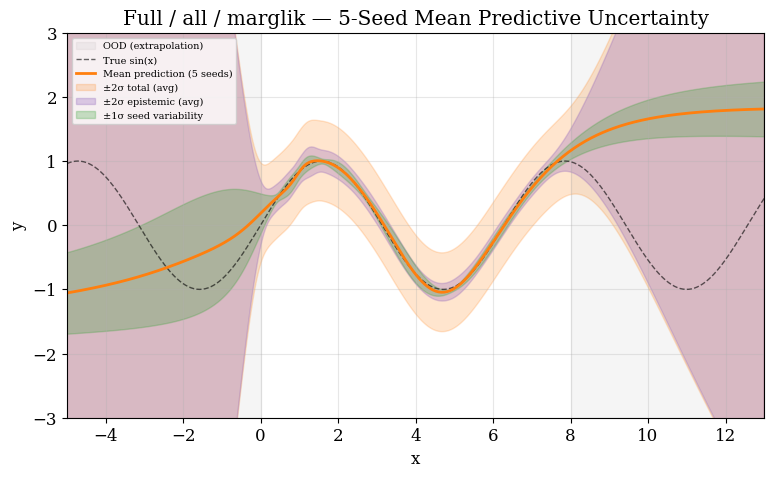

  Saved: 5seed_sinusoid_full_all_marglik_prediction.png


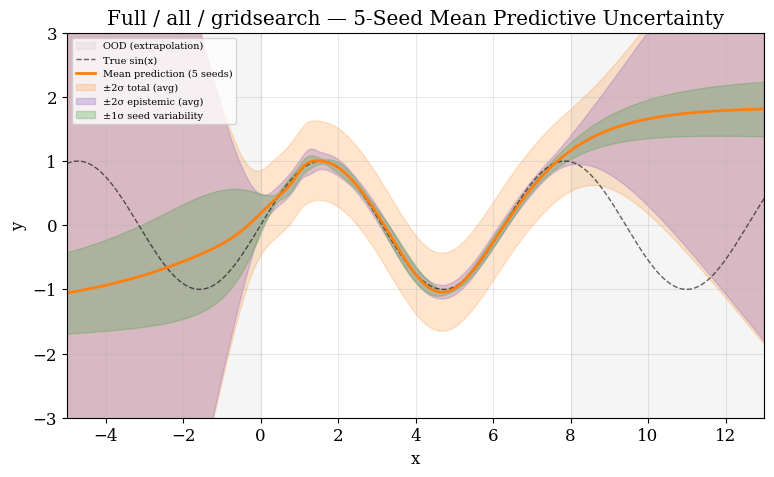

  Saved: 5seed_sinusoid_full_all_gridsearch_prediction.png


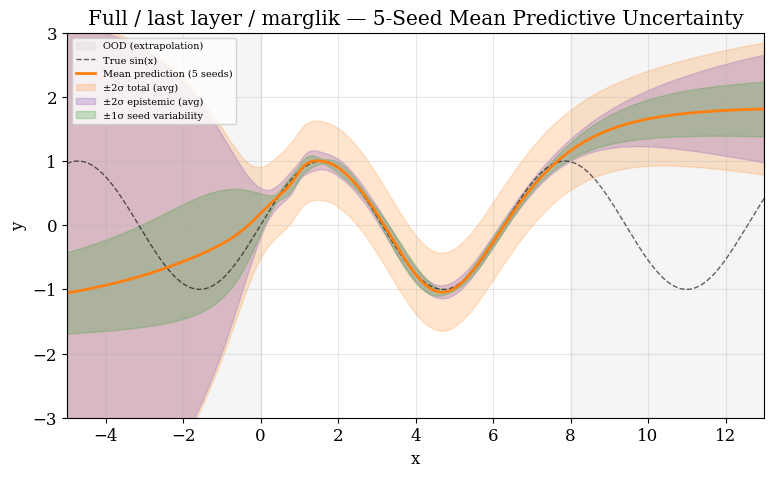

  Saved: 5seed_sinusoid_full_last_layer_marglik_prediction.png


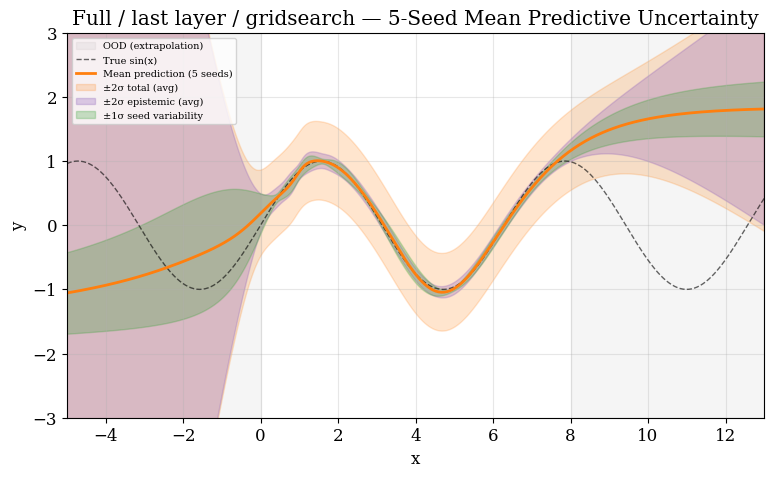

  Saved: 5seed_sinusoid_full_last_layer_gridsearch_prediction.png


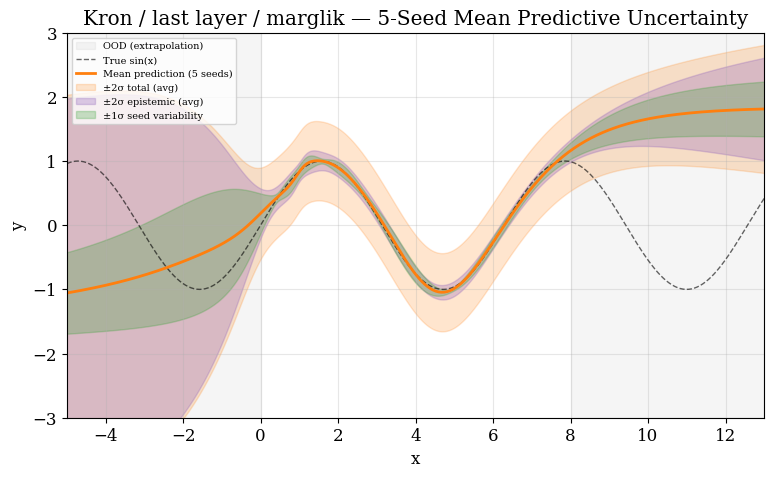

  Saved: 5seed_sinusoid_kron_last_layer_marglik_prediction.png


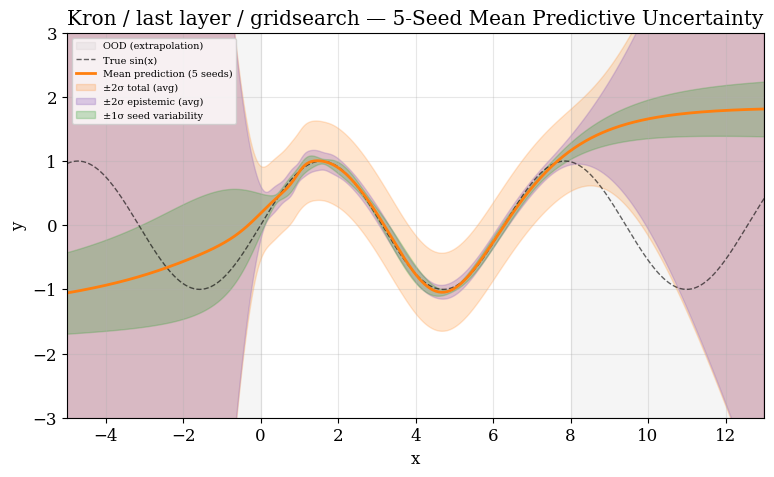

  Saved: 5seed_sinusoid_kron_last_layer_gridsearch_prediction.png


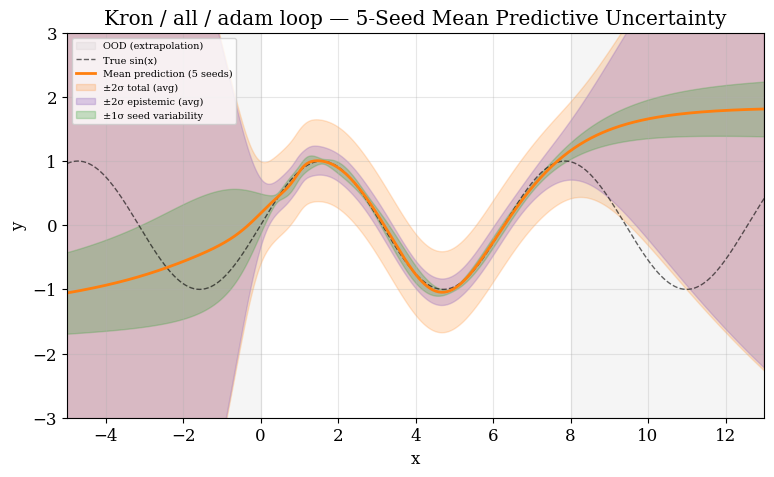

  Saved: 5seed_sinusoid_kron_all_adam_loop_prediction.png


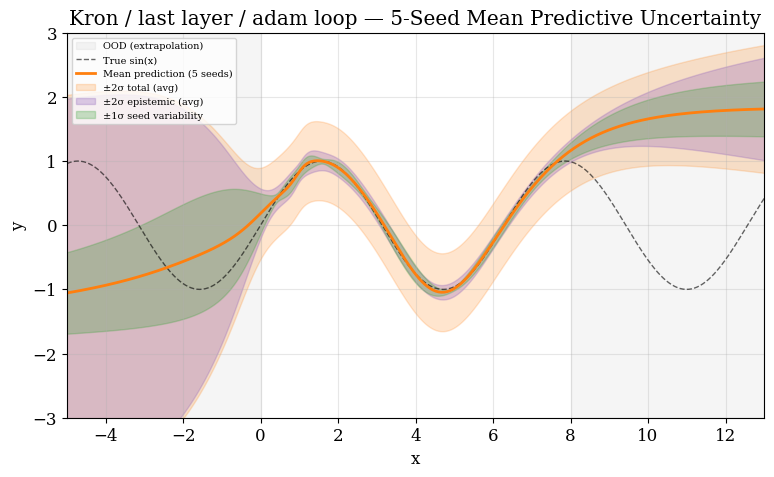

  Saved: 5seed_sinusoid_kron_last_layer_adam_loop_prediction.png

Done: 12 prediction figures


In [6]:
# Per-variant prediction figures: mean prediction ± uncertainty, averaged across seeds
for spec in variant_specs:
    vname = spec["variant_name"]; title = spec["plot_title"]

    all_mus  = np.stack([all_seed_preds[s][vname][0] for s in SEEDS])  # (S, N)
    all_epis = np.stack([all_seed_preds[s][vname][1] for s in SEEDS])  # (S, N)
    all_sigs = [all_seed_preds[s][vname][2] for s in SEEDS]

    mean_mu  = all_mus.mean(axis=0)
    std_mu   = all_mus.std(axis=0)
    mean_epi = all_epis.mean(axis=0)
    mean_sig = float(np.mean(all_sigs))
    mean_total = np.sqrt(mean_epi**2 + mean_sig**2)

    fig, ax = plt.subplots(1, 1, figsize=(9, 5))
    ax.axvspan(-5, TRAIN_LO, color="gray", alpha=0.08)
    ax.axvspan(TRAIN_HI, 13, color="gray", alpha=0.08, label="OOD (extrapolation)")
    ax.plot(x_grid, np.sin(x_grid), "k--", lw=1, alpha=0.6, label="True sin(x)")
    ax.plot(x_grid, mean_mu, color="tab:orange", lw=2, label="Mean prediction (5 seeds)")
    ax.fill_between(x_grid, mean_mu-2*mean_total, mean_mu+2*mean_total,
                    color="tab:orange", alpha=0.20, label="±2σ total (avg)")
    ax.fill_between(x_grid, mean_mu-2*mean_epi, mean_mu+2*mean_epi,
                    color="tab:purple", alpha=0.30, label="±2σ epistemic (avg)")
    ax.fill_between(x_grid, mean_mu-std_mu, mean_mu+std_mu,
                    color="tab:green", alpha=0.25, label="±1σ seed variability")
    ax.set_xlim(-5, 13); ax.set_ylim(-3, 3)
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.set_title(f"{title} — 5-Seed Mean Predictive Uncertainty")
    ax.legend(loc="upper left", fontsize=7); ax.grid(True, alpha=0.3)
    fig.savefig(os.path.join(FIGURES_DIR, f"5seed_sinusoid_{vname}_prediction.png"),
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: 5seed_sinusoid_{vname}_prediction.png")
print(f"\nDone: {len(variant_specs)} prediction figures")


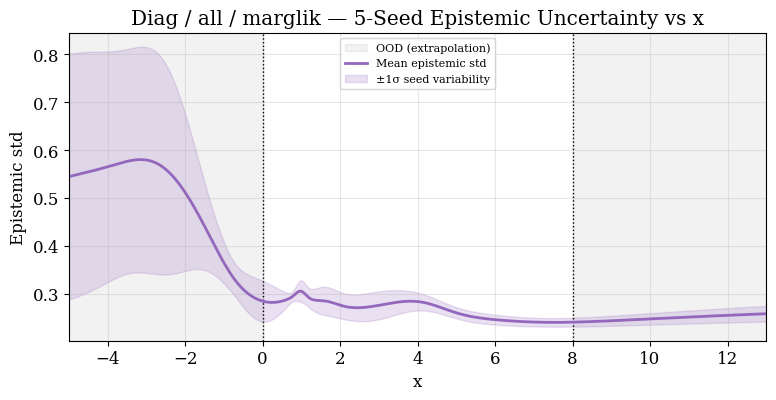

  Saved: 5seed_sinusoid_diag_all_marglik_ood_epistemic.png


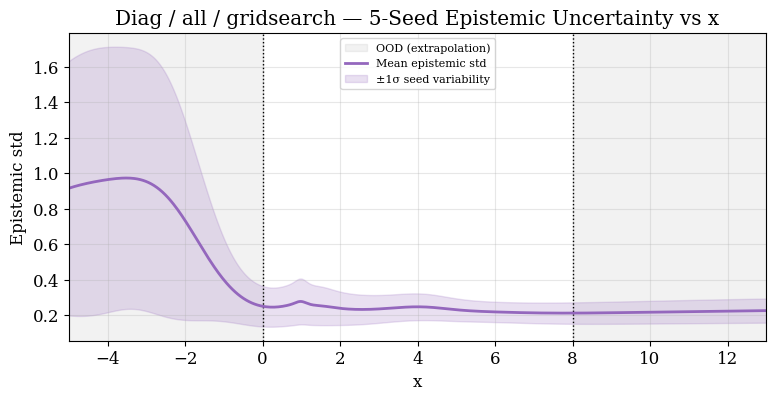

  Saved: 5seed_sinusoid_diag_all_gridsearch_ood_epistemic.png


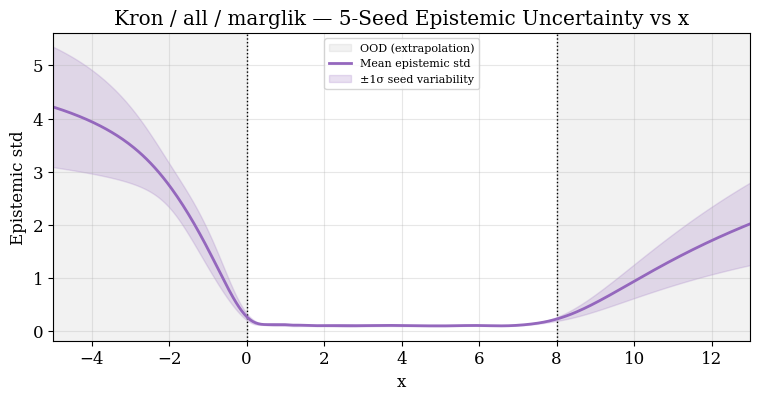

  Saved: 5seed_sinusoid_kron_all_marglik_ood_epistemic.png


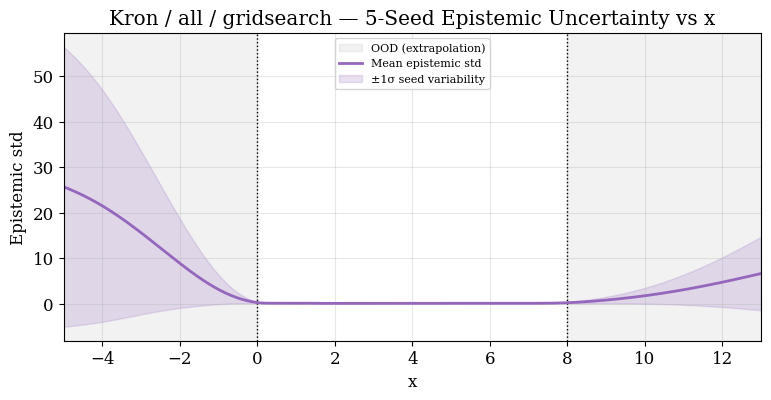

  Saved: 5seed_sinusoid_kron_all_gridsearch_ood_epistemic.png


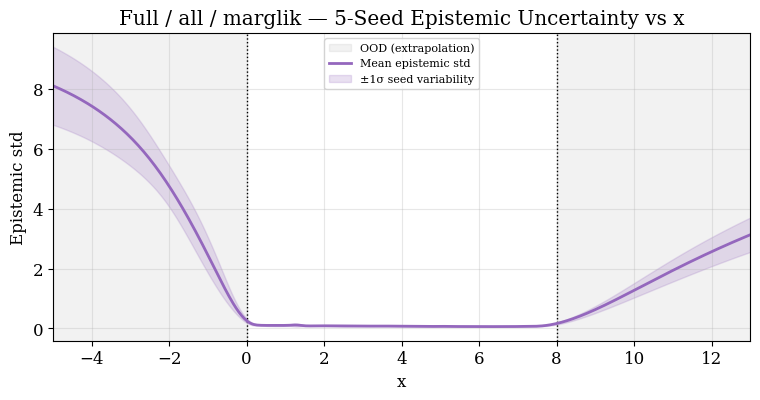

  Saved: 5seed_sinusoid_full_all_marglik_ood_epistemic.png


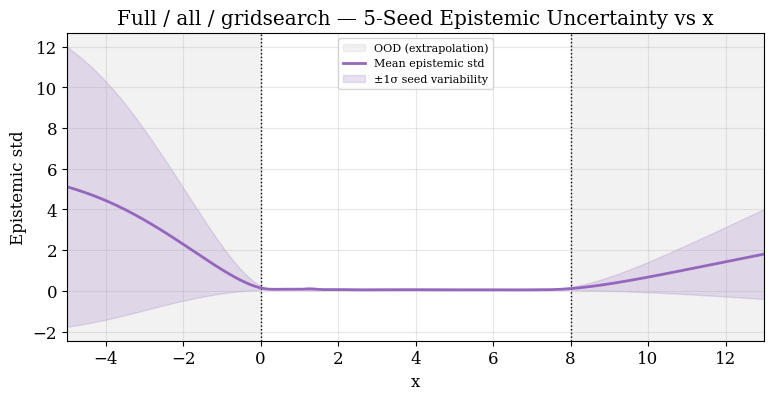

  Saved: 5seed_sinusoid_full_all_gridsearch_ood_epistemic.png


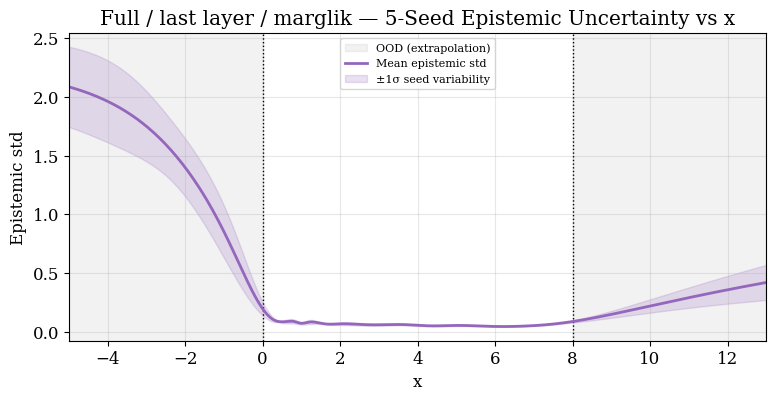

  Saved: 5seed_sinusoid_full_last_layer_marglik_ood_epistemic.png


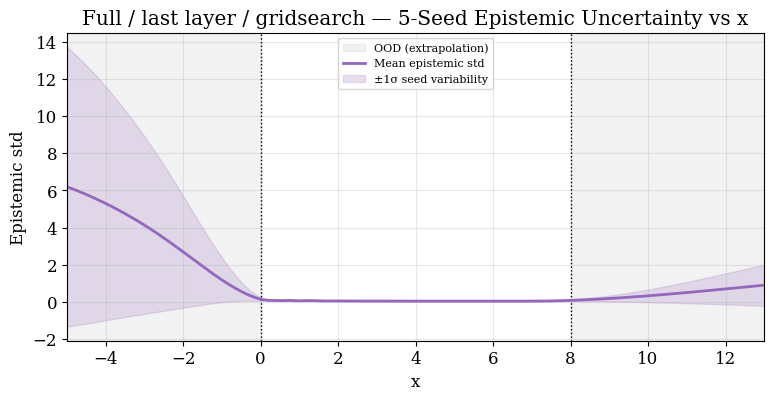

  Saved: 5seed_sinusoid_full_last_layer_gridsearch_ood_epistemic.png


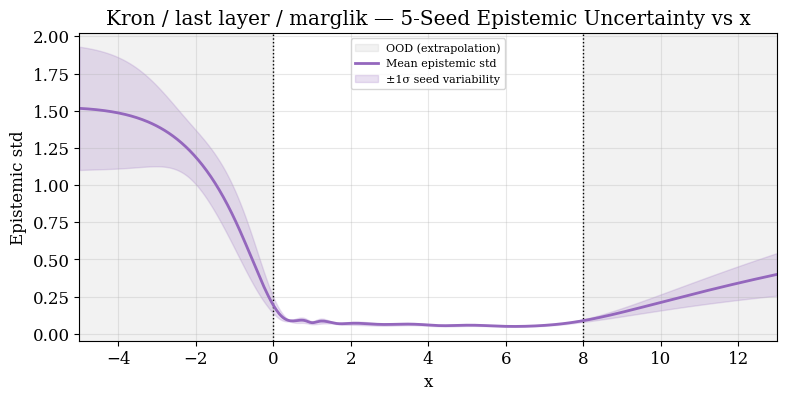

  Saved: 5seed_sinusoid_kron_last_layer_marglik_ood_epistemic.png


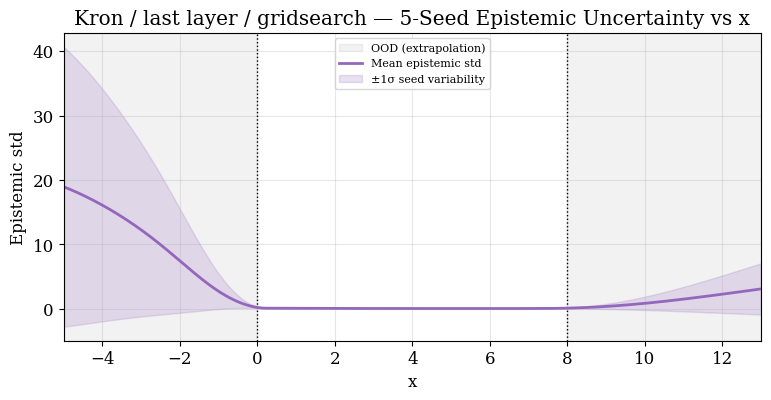

  Saved: 5seed_sinusoid_kron_last_layer_gridsearch_ood_epistemic.png


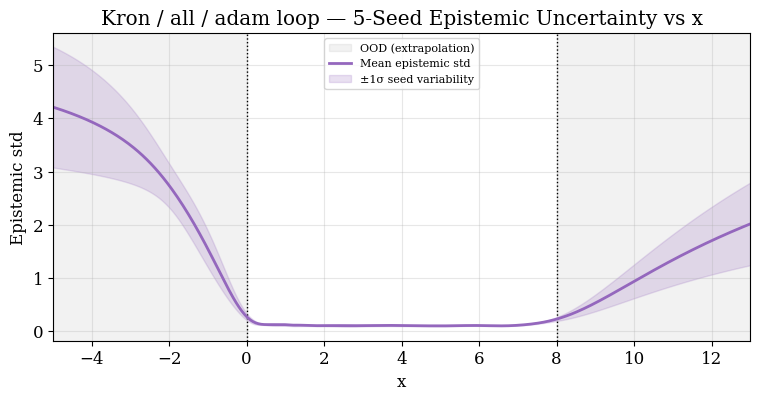

  Saved: 5seed_sinusoid_kron_all_adam_loop_ood_epistemic.png


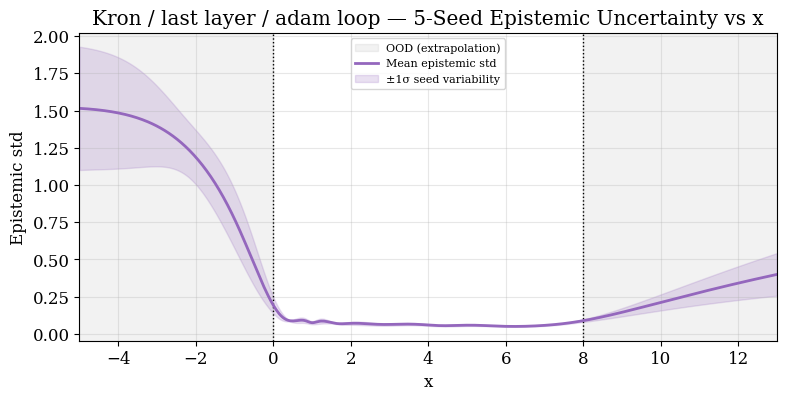

  Saved: 5seed_sinusoid_kron_last_layer_adam_loop_ood_epistemic.png

Done: 12 OOD epistemic figures


In [7]:
# Per-variant OOD epistemic figures: mean epistemic std ± seed variability
for spec in variant_specs:
    vname = spec["variant_name"]; title = spec["plot_title"]

    all_epis = np.stack([all_seed_preds[s][vname][1] for s in SEEDS])  # (S, N)
    mean_epi = all_epis.mean(axis=0)
    std_epi  = all_epis.std(axis=0)

    fig, ax = plt.subplots(1, 1, figsize=(9, 4))
    ax.axvspan(-5, TRAIN_LO, color="gray", alpha=0.10, label="OOD (extrapolation)")
    ax.axvspan(TRAIN_HI, 13, color="gray", alpha=0.10)
    ax.axvline(TRAIN_LO, color="k", ls=":", lw=1)
    ax.axvline(TRAIN_HI, color="k", ls=":", lw=1)
    ax.plot(x_grid, mean_epi, color="tab:purple", lw=2, label="Mean epistemic std")
    ax.fill_between(x_grid, mean_epi-std_epi, mean_epi+std_epi,
                    color="tab:purple", alpha=0.20, label="±1σ seed variability")
    ax.set_xlim(-5, 13)
    ax.set_xlabel("x"); ax.set_ylabel("Epistemic std")
    ax.set_title(f"{title} — 5-Seed Epistemic Uncertainty vs x")
    ax.legend(loc="upper center", fontsize=8); ax.grid(True, alpha=0.3)
    fig.savefig(os.path.join(FIGURES_DIR, f"5seed_sinusoid_{vname}_ood_epistemic.png"),
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: 5seed_sinusoid_{vname}_ood_epistemic.png")
print(f"\nDone: {len(variant_specs)} OOD epistemic figures")


  Seed 711: calibration done for 12 variants
  Seed 42: calibration done for 12 variants
  Seed 123: calibration done for 12 variants
  Seed 456: calibration done for 12 variants
  Seed 789: calibration done for 12 variants


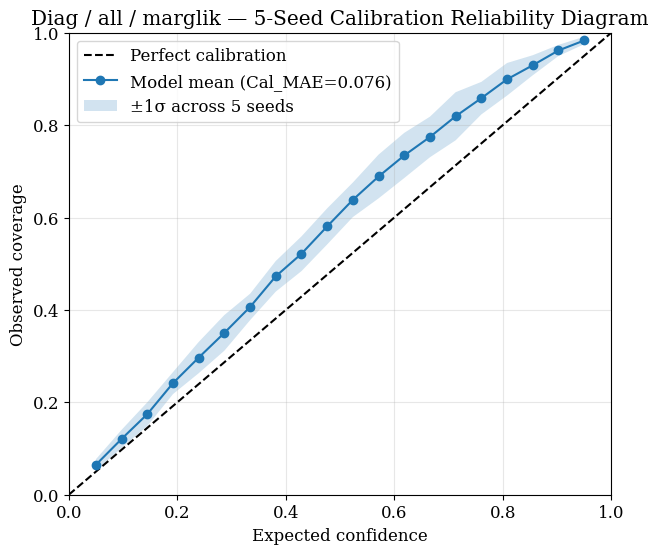

  Saved: 5seed_sinusoid_diag_all_marglik_calibration.png


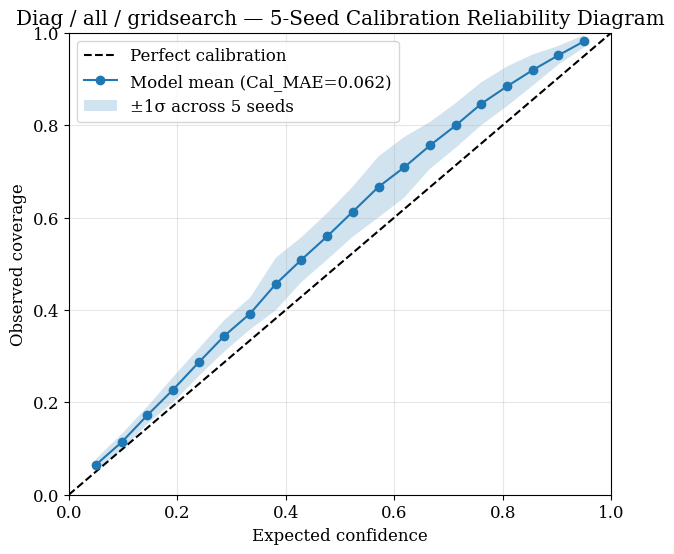

  Saved: 5seed_sinusoid_diag_all_gridsearch_calibration.png


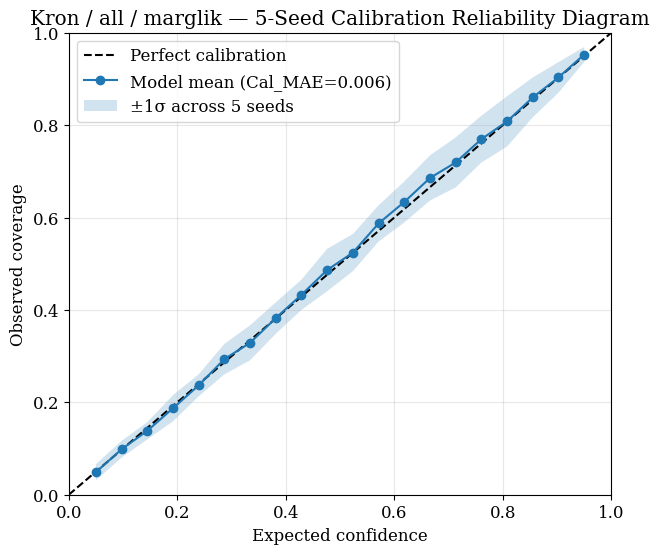

  Saved: 5seed_sinusoid_kron_all_marglik_calibration.png


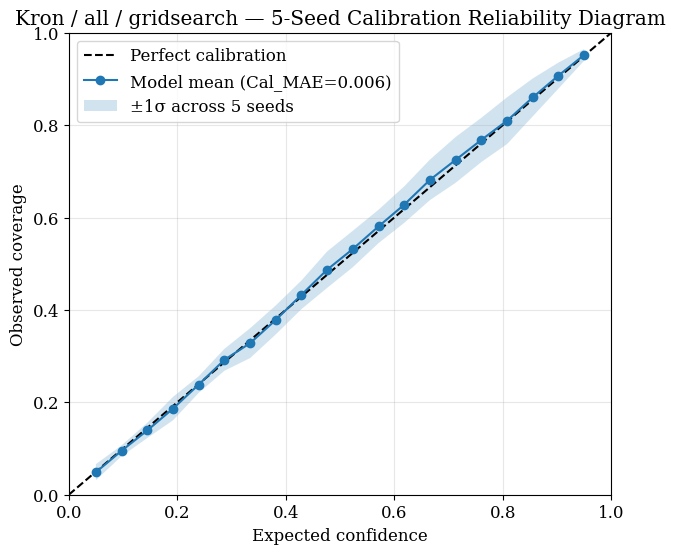

  Saved: 5seed_sinusoid_kron_all_gridsearch_calibration.png


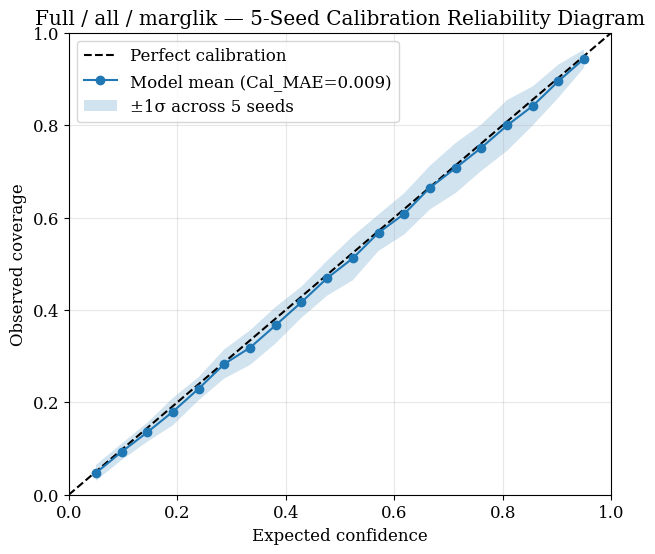

  Saved: 5seed_sinusoid_full_all_marglik_calibration.png


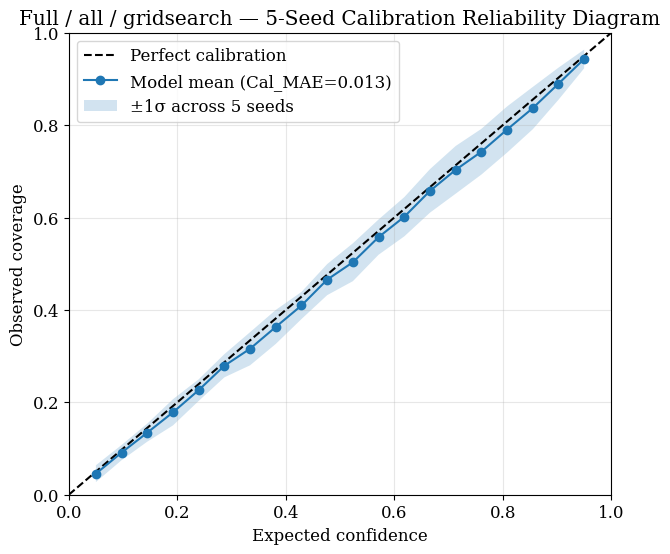

  Saved: 5seed_sinusoid_full_all_gridsearch_calibration.png


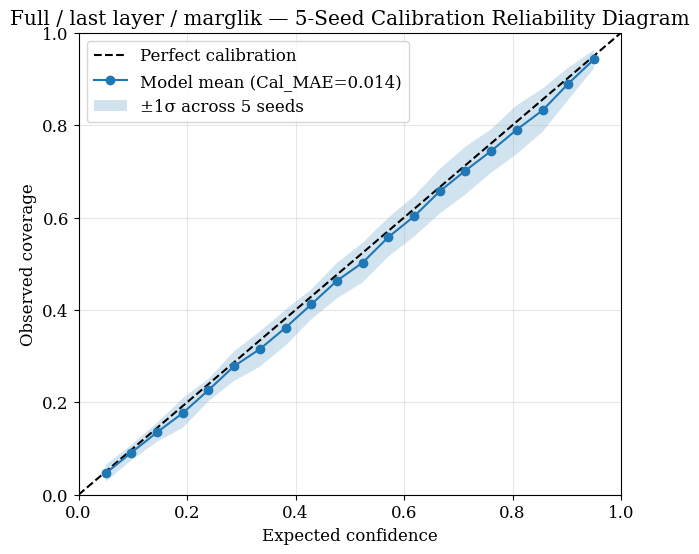

  Saved: 5seed_sinusoid_full_last_layer_marglik_calibration.png


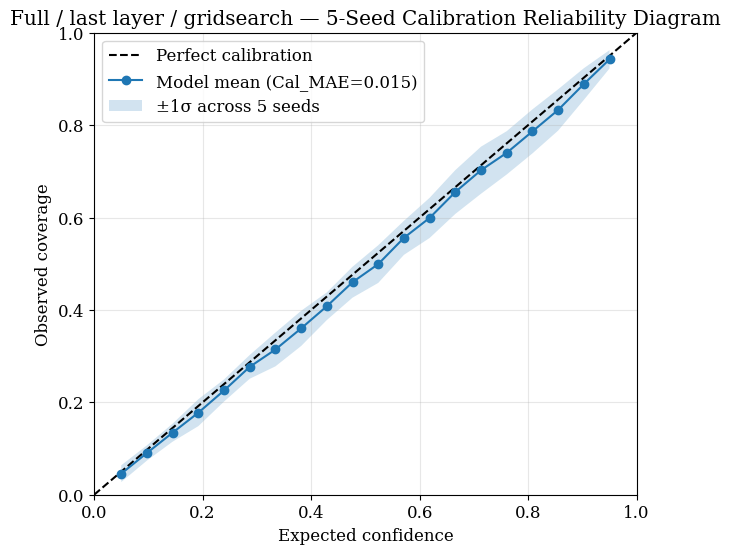

  Saved: 5seed_sinusoid_full_last_layer_gridsearch_calibration.png


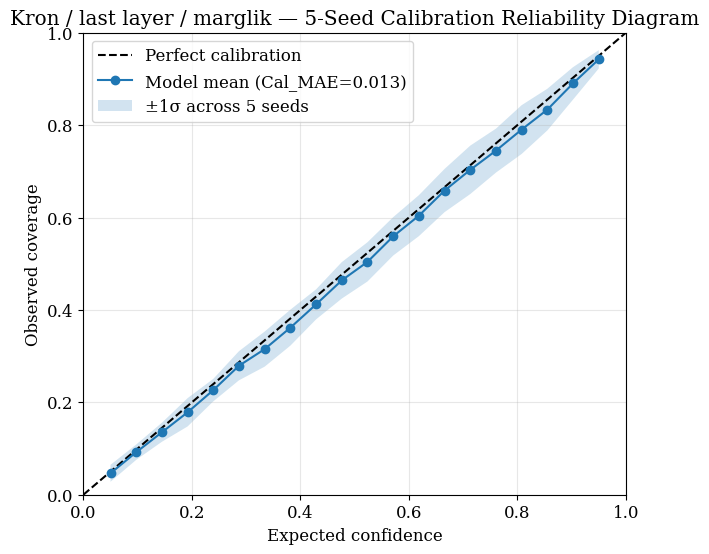

  Saved: 5seed_sinusoid_kron_last_layer_marglik_calibration.png


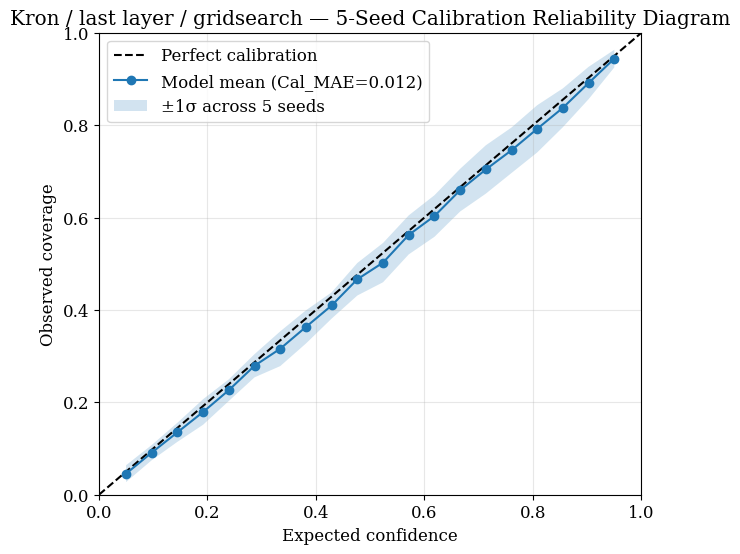

  Saved: 5seed_sinusoid_kron_last_layer_gridsearch_calibration.png


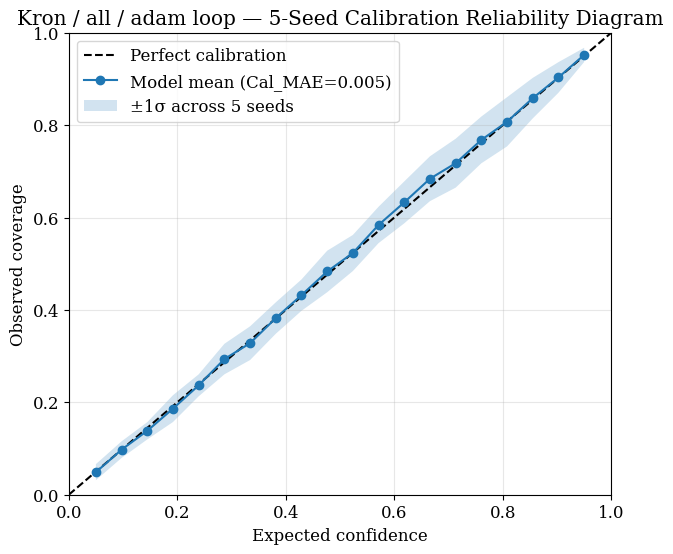

  Saved: 5seed_sinusoid_kron_all_adam_loop_calibration.png


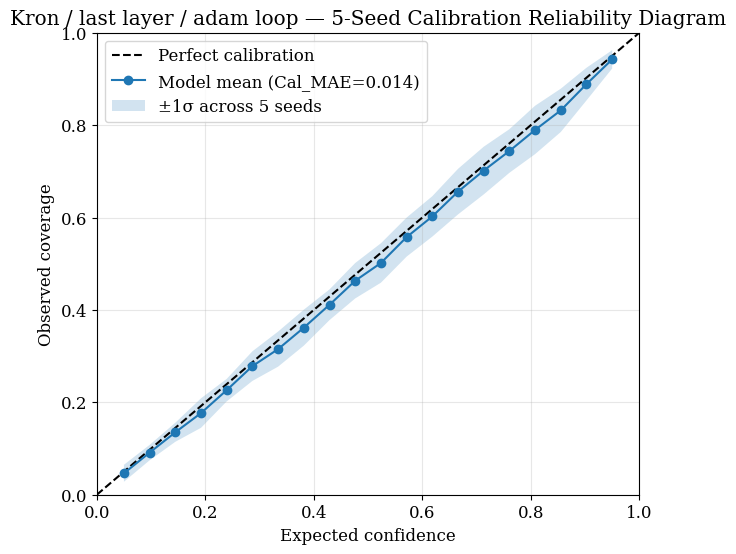

  Saved: 5seed_sinusoid_kron_last_layer_adam_loop_calibration.png

Done: 12 calibration figures


In [8]:
# Per-variant calibration curves: mean ± std across seeds
conf_levels = np.linspace(0.05, 0.95, 20)
seed_calibration = {seed: {} for seed in SEEDS}

for seed in SEEDS:
    _d = load_sinusoid(n_data=150, sigma_noise=sigma_noise, batch_size=150, seed=seed,
                       device=torch.device("cpu"))
    X_test_id_s = _d["X_test_id"]
    y_test_id_s = _d["y_test_id"].flatten().numpy()

    for spec in variant_specs:
        vname = spec["variant_name"]
        la = all_seed_la.get(seed, {}).get(vname)
        if la is None:
            print(f"  Warning: {vname} seed {seed} not in memory"); continue
        sigma = float(la.sigma_noise.item())
        mu_id, epi_id = la_predict(la, X_test_id_s)
        total_id = np.sqrt(epi_id**2 + sigma**2)
        resid = y_test_id_s - mu_id
        z_abs = np.abs(resid / np.clip(total_id, 1e-12, None))
        observed = np.array([float(np.mean(z_abs <= _norm.ppf((1+c)/2))) for c in conf_levels])
        seed_calibration[seed][vname] = observed
    print(f"  Seed {seed}: calibration done for {len(seed_calibration[seed])} variants")

for spec in variant_specs:
    vname = spec["variant_name"]; title = spec["plot_title"]
    avail = [seed_calibration[s][vname] for s in SEEDS if vname in seed_calibration[s]]
    if not avail:
        print(f"  Skipping {vname} (no data)"); continue
    obs_matrix = np.stack(avail)
    mean_obs = obs_matrix.mean(axis=0)
    std_obs  = obs_matrix.std(axis=0)
    cal_mae  = float(np.mean(np.abs(mean_obs - conf_levels)))

    fig, ax = plt.subplots(1, 1, figsize=(7, 6))
    ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
    ax.plot(conf_levels, mean_obs, "o-", label=f"Model mean (Cal_MAE={cal_mae:.3f})")
    ax.fill_between(conf_levels, mean_obs - std_obs, mean_obs + std_obs,
                    alpha=0.2, label=f"±1σ across {len(SEEDS)} seeds")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel("Expected confidence"); ax.set_ylabel("Observed coverage")
    ax.set_title(f"{title} — 5-Seed Calibration Reliability Diagram")
    ax.legend(); ax.grid(True, alpha=0.3)
    fig.savefig(os.path.join(FIGURES_DIR, f"5seed_sinusoid_{vname}_calibration.png"),
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: 5seed_sinusoid_{vname}_calibration.png")
print(f"\nDone: {len(variant_specs)} calibration figures")